In [1]:
!pip install tslearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.9/387.9 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 104.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 19.5 MB/s eta 0:00:00
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.64.0 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.64.0 which is incompatible.


In [2]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

from sklearn.metrics import accuracy_score, f1_score
from tslearn.datasets import UCR_UEA_datasets

In [3]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

print("Seed fixed:", seed)

Seed fixed: 42


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [5]:
ds = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = ds.load_dataset("LSST")

In [6]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("Unique labels:", np.unique(y_train))
print("Number of classes:", len(np.unique(y_train)))

X_train shape: (2459, 36, 6)
y_train shape: (2459,)
X_test shape: (2466, 36, 6)
y_test shape: (2466,)
Unique labels: ['15' '16' '42' '52' '53' '6' '62' '64' '65' '67' '88' '90' '92' '95']
Number of classes: 14


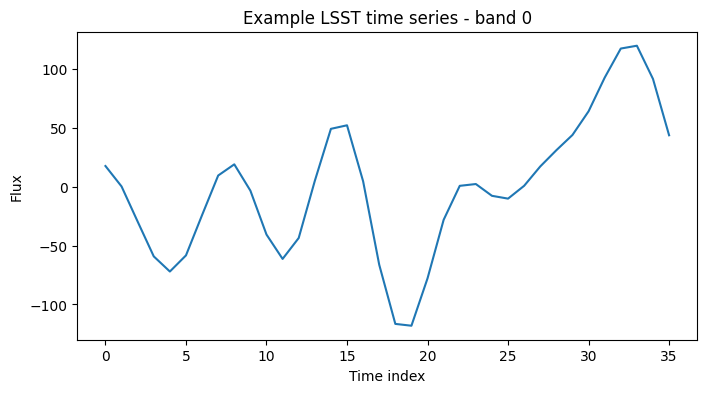

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(X_train[0, :, 0])
plt.title("Example LSST time series - band 0")
plt.xlabel("Time index")
plt.ylabel("Flux")
plt.show()

In [8]:
unique_labels = np.unique(y_train)

label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

y_train = np.array([label_to_idx[y] for y in y_train])
y_test = np.array([label_to_idx[y] for y in y_test])

print("Mapping:", label_to_idx)
print("Mapped labels:", np.unique(y_train))
print("num_classes:", len(unique_labels))

Mapping: {np.str_('15'): 0, np.str_('16'): 1, np.str_('42'): 2, np.str_('52'): 3, np.str_('53'): 4, np.str_('6'): 5, np.str_('62'): 6, np.str_('64'): 7, np.str_('65'): 8, np.str_('67'): 9, np.str_('88'): 10, np.str_('90'): 11, np.str_('92'): 12, np.str_('95'): 13}
Mapped labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]
num_classes: 14


In [9]:
mean = X_train.mean()
std = X_train.std()

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

print("Train mean after normalization:", X_train.mean())
print("Train std after normalization:", X_train.std())

Train mean after normalization: 1.3698653499208173e-17
Train std after normalization: 0.9999999999999998


In [10]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([2459, 36, 6]) torch.Size([2459])
torch.Size([2466, 36, 6]) torch.Size([2466])


In [11]:
full_train_dataset = TensorDataset(X_train, y_train)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)

test_dataset = TensorDataset(X_test, y_test)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 1967
Validation size: 492
Test size: 2466


In [12]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # shape: (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x shape: (batch, seq_len, d_model)
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]

In [13]:
class TransformerClassifier(nn.Module):
    def __init__(
        self,
        input_dim=6,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.1,
        num_classes=14
    ):
        super().__init__()

        self.input_projection = nn.Linear(input_dim, d_model)
        self.positional_encoding = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # x shape: (batch, time, channels)
        x = self.input_projection(x)          # (batch, time, d_model)
        x = self.positional_encoding(x)       # (batch, time, d_model)
        x = self.transformer_encoder(x)       # (batch, time, d_model)

        x = x.mean(dim=1)                     # global average pooling over time
        x = self.dropout(x)
        logits = self.classifier(x)

        return logits

In [20]:
num_classes = len(unique_labels)

model = TransformerClassifier(
    input_dim=X_train.shape[2],
    d_model=128,
    nhead=4,
    num_layers=3,
    dim_feedforward=256,
    dropout=0.1,
    num_classes=num_classes
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)

TransformerClassifier(
  (input_projection): Linear(in_features=6, out_features=128, bias=True)
  (positional_encoding): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (classifier): Linear(in_features=128, out_features=14, bias=True)
)


In [21]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            total_loss += loss.item() * xb.size(0)

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(yb.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average="macro")

    return avg_loss, acc, macro_f1

In [22]:
num_epochs = 20

history = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": []
}

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_f1={val_f1:.4f}"
    )

Epoch 01/20 | train_loss=2.1292 | val_loss=2.0965 | val_acc=0.3557 | val_f1=0.0986
Epoch 02/20 | train_loss=1.9914 | val_loss=2.0314 | val_acc=0.3699 | val_f1=0.1074
Epoch 03/20 | train_loss=1.9392 | val_loss=1.8554 | val_acc=0.4126 | val_f1=0.1461
Epoch 04/20 | train_loss=1.9170 | val_loss=1.9367 | val_acc=0.4167 | val_f1=0.1620
Epoch 05/20 | train_loss=1.8043 | val_loss=1.8035 | val_acc=0.4167 | val_f1=0.1556
Epoch 06/20 | train_loss=1.7623 | val_loss=1.7520 | val_acc=0.4472 | val_f1=0.2094
Epoch 07/20 | train_loss=1.7421 | val_loss=1.7772 | val_acc=0.4472 | val_f1=0.3029
Epoch 08/20 | train_loss=1.6492 | val_loss=1.6430 | val_acc=0.4736 | val_f1=0.2907
Epoch 09/20 | train_loss=1.5514 | val_loss=1.5421 | val_acc=0.5020 | val_f1=0.3787
Epoch 10/20 | train_loss=1.5369 | val_loss=1.6868 | val_acc=0.4451 | val_f1=0.3135
Epoch 11/20 | train_loss=1.4510 | val_loss=1.5295 | val_acc=0.4736 | val_f1=0.3541
Epoch 12/20 | train_loss=1.4072 | val_loss=1.4798 | val_acc=0.5142 | val_f1=0.3072
Epoc

In [23]:
test_loss, test_acc, test_f1 = evaluate(model, test_loader, criterion, device)

print("\nFinal test results:")
print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_acc:.4f}")
print(f"Test macro-F1 : {test_f1:.4f}")


Final test results:
Test loss     : 1.2962
Test accuracy : 0.5722
Test macro-F1 : 0.4255


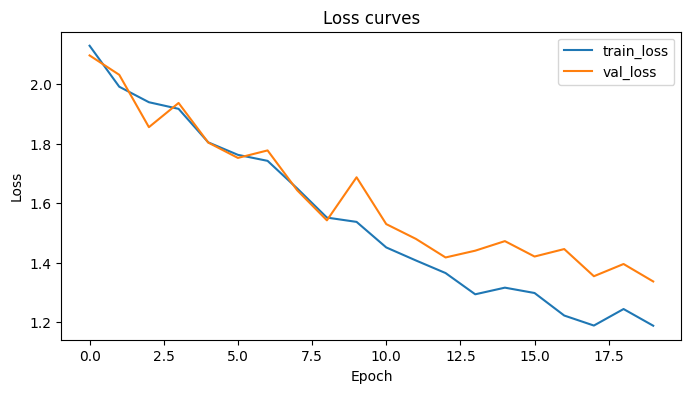

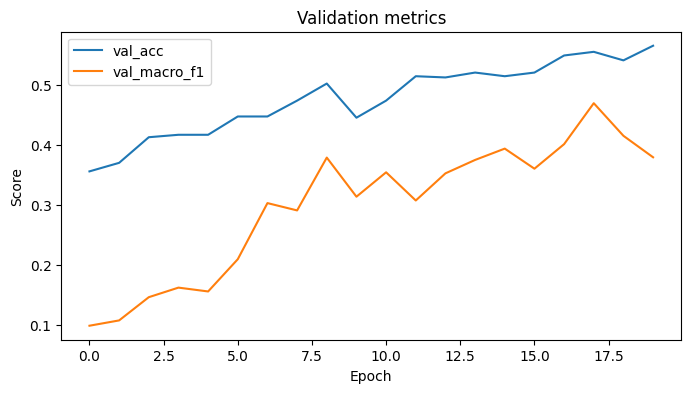

In [24]:
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history["val_acc"], label="val_acc")
plt.plot(history["val_f1"], label="val_macro_f1")
plt.legend()
plt.title("Validation metrics")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.show()

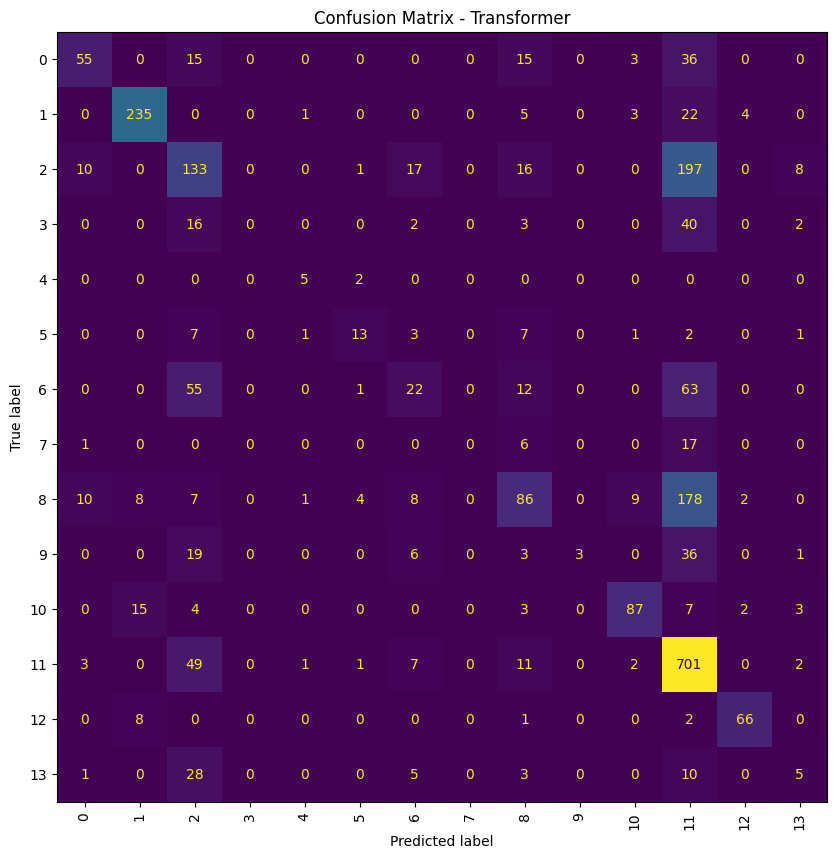

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_targets.extend(yb.numpy())

cm = confusion_matrix(all_targets, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Confusion Matrix - Transformer")
plt.show()